# Demystifying Model Behavior: From Genetic Risk to Binary Classification

Welcome to this interactive notebook! In this space, we are going to explore exactly how machine learning models and explainability tools behave when we shift the underlying "ground truth" of categorical data predicting a categorical outcome. 

In the real world of clinical genomics and bioinformatics, we often feed discrete data (like genotypes coded as 0, 1, and 2) into an algorithm like XGBoost to predict a **binary outcome**—such as whether a patient has a specific disease or not (coded as 1 or 0). But how do we know *what* the model is actually learning? To answer this, we are going to play the role of the "Creator." We will generate synthetic datasets where **we know the exact biological and probabilistic mechanisms** governing the binary target ($y$). 

By knowing the absolute, indisputable truth, we can test how well Traditional Statistics (Chi-Square & Logistic Regression) and Machine Learning (XGBoost Classifier + SHAP) uncover that truth across three increasingly realistic clinical scenarios.

## The Three Scenarios We Will Explore

We will run an end-to-end analytical pipeline—training, evaluating, and explaining—on the following three cases:

### Case 1: The Simple Logistic World (Pure Main Effects)
* **The Reality:** The binary target $y$ (Disease vs. Healthy) is driven by independent genes acting alone. These genes increase or decrease the hidden "latent risk" (log-odds) of the disease. This risk is then converted into a probability using a sigmoid function, and nature rolls the dice (a binomial distribution) to assign the final 0 or 1.
* **The Goal:** Establish a baseline. We will see how perfectly traditional methods handle simple categorical-to-categorical relationships. We will test if a simple bivariate test (Chi-Square) flags the right genes, how multivariate Logistic Regression captures the true log-odds weights, and how XGBoost + SHAP represent main effects in a probability space.

### Case 2: The Complex Biological World (Epistatic Interactions)
* **The Reality:** Biology is rarely strictly independent; features now interact with one another to influence the log-odds of the disease (e.g., Gene A only increases disease risk if Gene B is also mutated, known as epistasis). 
* **The Goal:** Observe the divergence between traditional stats and machine learning. A standard Chi-Square test evaluates genes one by one and might miss interacting pairs, while Logistic Regression will struggle without manual interaction terms. Conversely, XGBoost's tree structure will naturally map the combinations. We will use SHAP interaction values to crack open the model and visualize exactly how these genes are working together.

### Case 3: The Incomplete World (Missing Heritability / Hidden Features)
* **The Reality:** We generate a complex dataset with interactions, but deliberately *hide* critical contributing genes or environmental factors from the model. 
* **The Goal:** Mimic messy, real-world clinical scenarios where we simply lack all the necessary data. We will watch our classification evaluation metrics (like Accuracy, ROC AUC, and Log Loss) degrade, and use SHAP to see how the model tries (and often fails) to compensate for the missing puzzle pieces.

## Our Toolkit
To accomplish this, we will be utilizing:
* **Custom Generators:** `numpy` and `pandas` to build the exact latent log-odds equations, apply sigmoid probabilities, and sample categorical binomial outcomes.
* **Baseline Modeling:** `scipy.stats` (Chi-Square) for bivariate independence testing, and `statsmodels` (Logistic Regression) for traditional multivariate statistical significance.
* **Predictive Modeling:** `xgboost` (XGBClassifier) to natively handle categorical data and capture non-linear step functions and complex interactions for binary targets.
* **Explainability:** `shap` (SHapley Additive exPlanations) to trace global feature importance, visualize specific biological distributions in log-odds space via violin plots, and isolate pure variable interactions.

In [1]:
from XAI_test_3 import *

## simple linear combination test

### make example data 1

In [2]:

# 1. Generate Binary Data
X, _, y_binary, visible_features, _ = generate_synthetic_classification_data(
    num_inputs=10, 
    num_samples=5000, 
    num_contributing_features=(3, 5), 
    num_hidden_features=(0, 0), 
    weight_range=(-1.5, 1.5), 
    num_interactions=(0, 0), 
    interaction_weight_range=(-1.5, 1.5), 
    noise_std=0.5, 
    hidden_in_linear=False,           
    hidden_in_interactions=False,
)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)


--- Generative Model Info (Log-Odds Formulation) ---
Log-Odds (z) = 
  (0.62 * Feature_0 [dominant]) + 
  (0.50 * Feature_9 [additive]) + 
  (-0.43 * Feature_5 [additive]) + 
  (0.10 * Feature_6 [recessive]) 
  + Noise(0, 0.5)
Probability (P) = 1 / (1 + e^-z)
Class Output = Binomial(1, P)



### make the Traditional Baselines 

#### Chi-Square Test


--- Traditional Baseline 1: Chi-Square Independence Tests ---
Significant Features (p < 0.05) [Bivariate Test]:
  - Feature_9: p-value = 5.2130e-24
  - Feature_5: p-value = 2.9899e-17
  - Feature_0: p-value = 3.6746e-13


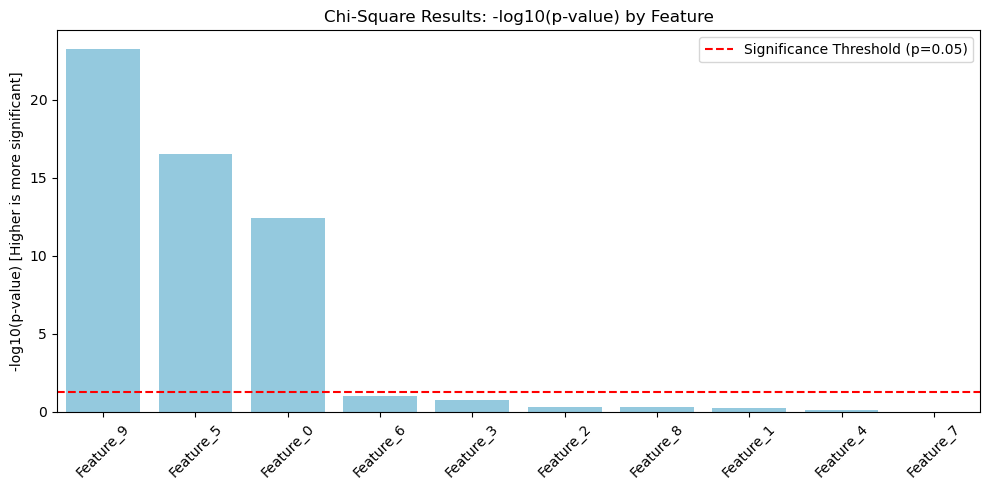

In [3]:

# 2a. Traditional Baseline 1 (Chi-Square Test)
perform_traditional_chi_square(X_train, y_train)


#### Logistic Regression


--- Traditional Baseline 2: Multivariate Logistic Regression ---
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3989
Method:                           MLE   Df Model:                           10
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                 0.04551
Time:                        14:21:52   Log-Likelihood:                -2545.4
converged:                       True   LL-Null:                       -2666.8
Covariance Type:            nonrobust   LLR p-value:                 1.827e-46
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0750      0.092      0.813      0.416      -0.106       0.256
Feature_0      0.3502      0.047      7.379      0.000       0.25

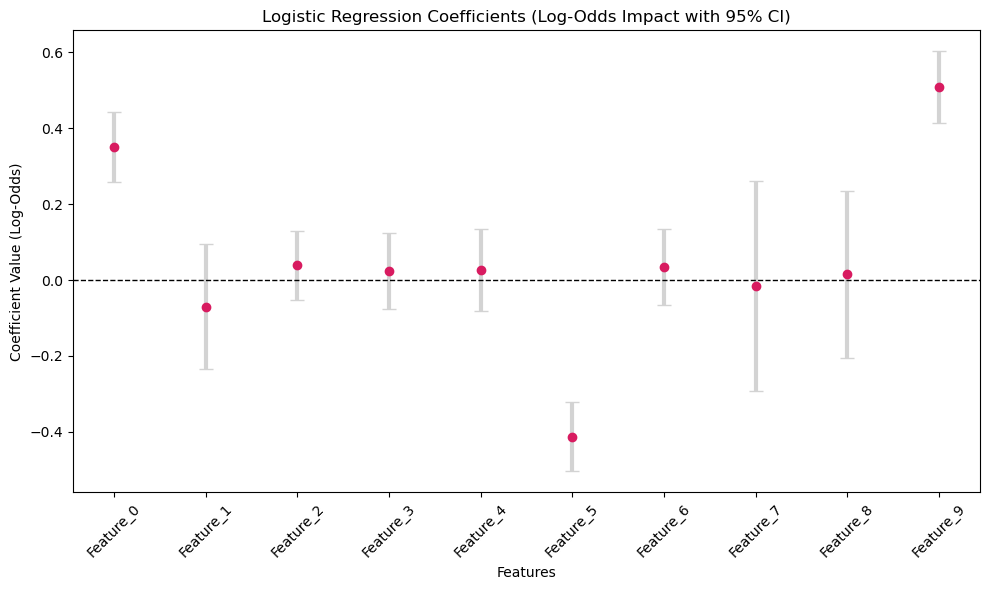

In [4]:

# 2b. Traditional Baseline 2 (Logistic Regression)
perform_traditional_logistic_regression(X_train, y_train)


### make a simple xgboost model for test 1

In [5]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost Classifier)
model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    objective='binary:logistic',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1. Evaluation
evaluate_xgb_classifier(model, X_test_cat, y_test)



--- XGBoost Classifier Performance (Testing) ---
Accuracy: 0.6010
ROC AUC:  0.5920
Log Loss: 0.6742



### look at XGBoost Native Importances

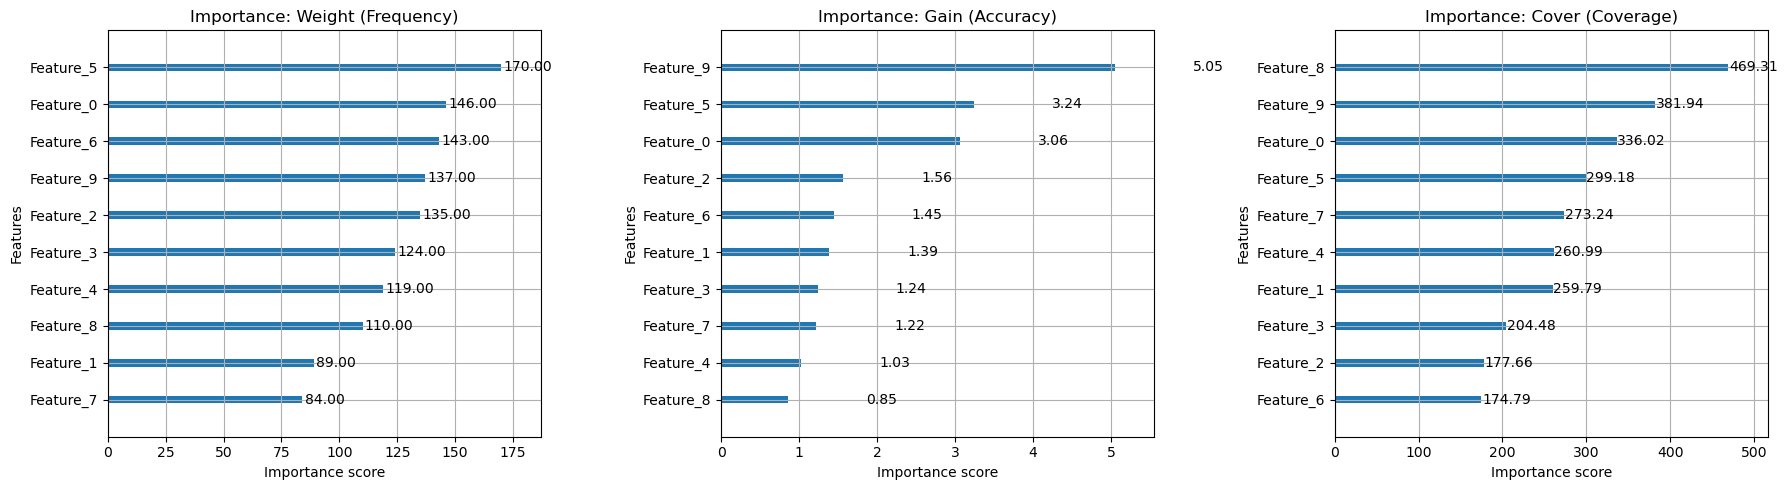

In [6]:

# 5.2. XGBoost Importances
plot_all_xgb_importances(model)


### try to use SHAP to find the influencing inputs

In [7]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

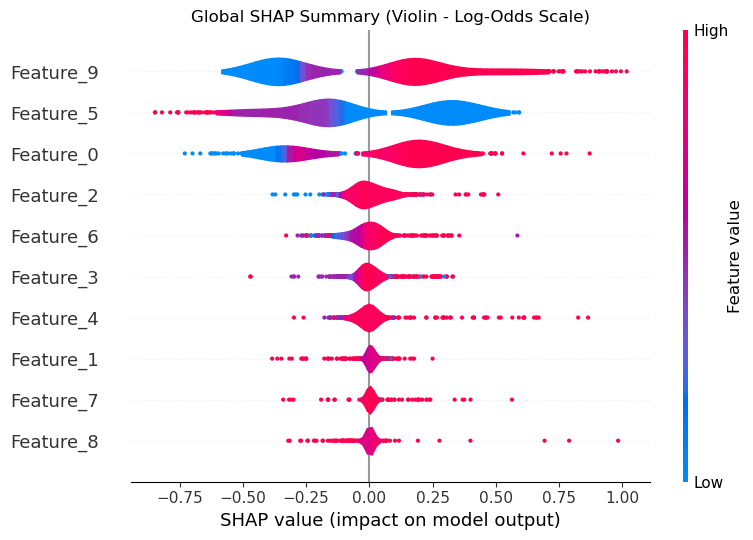

In [8]:

# Global SHAP Violin Summary
plt.title("Global SHAP Summary (Violin - Log-Odds Scale)")
shap.summary_plot(shap_values.values, X_test_cat.astype(float), plot_type="violin", show=False)
plt.show()


Generating SHAP violin grid for all features...


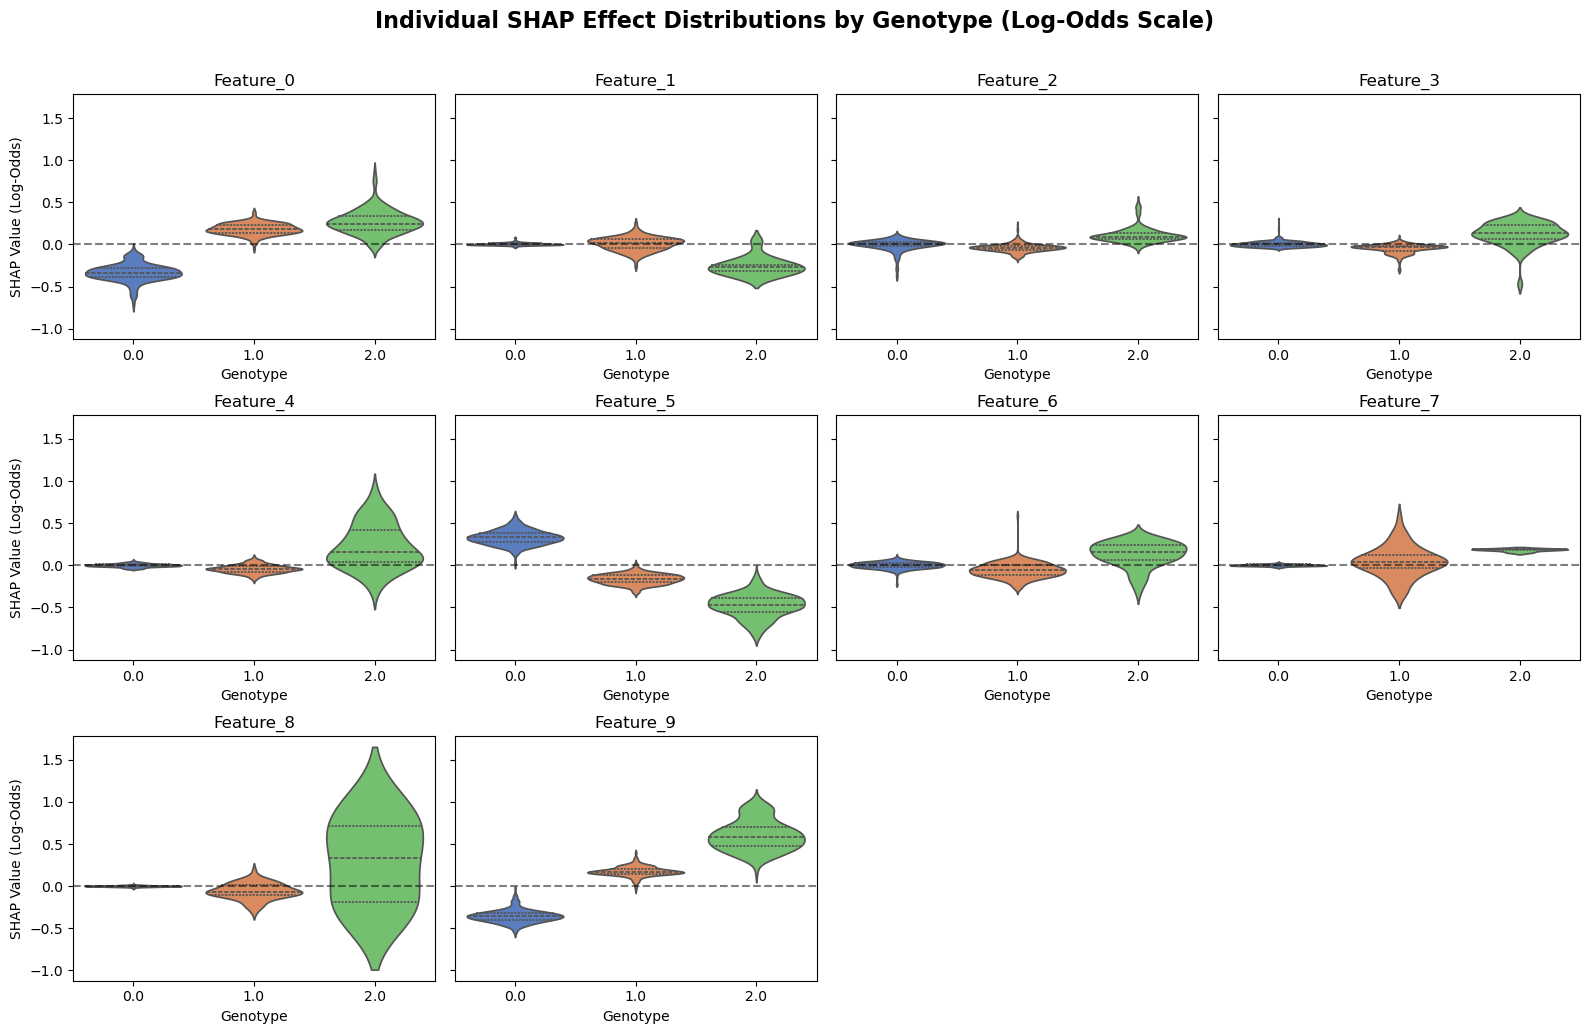

In [9]:

# 7. Individual Feature Violin Plots 
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we shouldn't see any


--- Computing SHAP Interaction Values ---


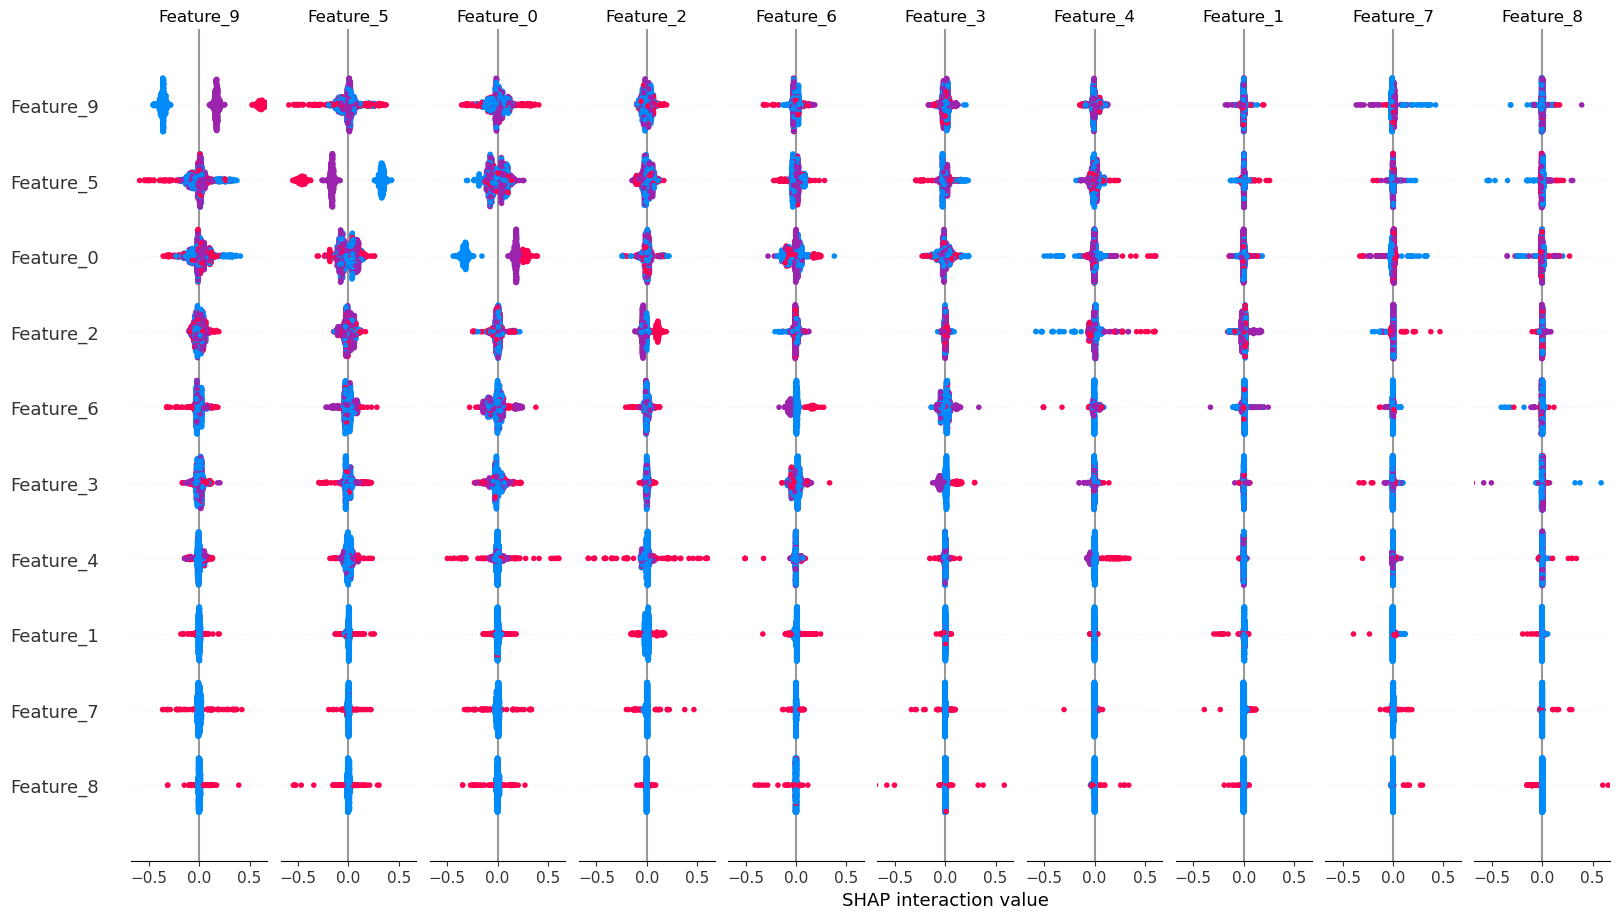


Strongest Interaction found by SHAP: Feature_5 & Feature_9


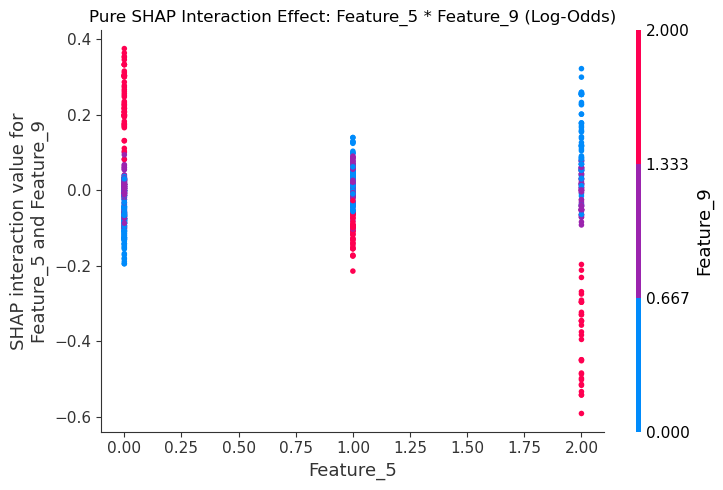

In [10]:

# 8. Deep Dive: Interactions
analyze_shap_interactions(model, X_test_cat)


#### SHAP summry

In [11]:

# Print numerical ranking
print_feature_importance(shap_values)



--- SHAP Feature Importance Ranking (Impact on Log-Odds) ---
  Feature_9: 0.3221
  Feature_5: 0.2845
  Feature_0: 0.2563
  Feature_2: 0.0617
  Feature_6: 0.0581
  Feature_3: 0.0468
  Feature_4: 0.0433
  Feature_1: 0.0212
  Feature_7: 0.0172
  Feature_8: 0.0163


['Feature_9',
 'Feature_5',
 'Feature_0',
 'Feature_2',
 'Feature_6',
 'Feature_3',
 'Feature_4',
 'Feature_1',
 'Feature_7',
 'Feature_8']

## test for linear combination with some feature interactions

### make example data 2

In [12]:

# 1. Generate Binary Data
X, _, y_binary, visible_features, _ = generate_synthetic_classification_data(
    num_inputs=10, 
    num_samples=5000, 
    num_contributing_features=(3, 5), 
    num_hidden_features=(0, 0), 
    weight_range=(-1.5, 1.5), 
    num_interactions=(2, 3), 
    interaction_weight_range=(-1.5, 1.5), 
    noise_std=0.5, 
    hidden_in_linear=False,           
    hidden_in_interactions=False,
)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)


--- Generative Model Info (Log-Odds Formulation) ---
Log-Odds (z) = 
  (1.49 * Feature_1 [dominant]) + 
  (1.40 * Feature_4 [additive]) + 
  (1.38 * Feature_6 [dominant]) + 
  (-1.18 * Feature_7 [additive]) + 
  (-1.08 * Feature_0 [additive]) + 
  (-0.54 * (Feature_2, Feature_8) [xor_interference]) + 
  (-0.33 * (Feature_8, Feature_9) [xor_interference]) 
  + Noise(0, 0.5)
Probability (P) = 1 / (1 + e^-z)
Class Output = Binomial(1, P)



### make the Traditional Baselines 

#### Chi-Square Test


--- Traditional Baseline 1: Chi-Square Independence Tests ---
Significant Features (p < 0.05) [Bivariate Test]:
  - Feature_7: p-value = 1.1101e-89
  - Feature_1: p-value = 2.3906e-52
  - Feature_6: p-value = 1.2136e-48
  - Feature_4: p-value = 1.2275e-16
  - Feature_0: p-value = 1.6650e-16
  - Feature_2: p-value = 2.4763e-08
  - Feature_8: p-value = 3.6972e-03
  - Feature_9: p-value = 8.2193e-03


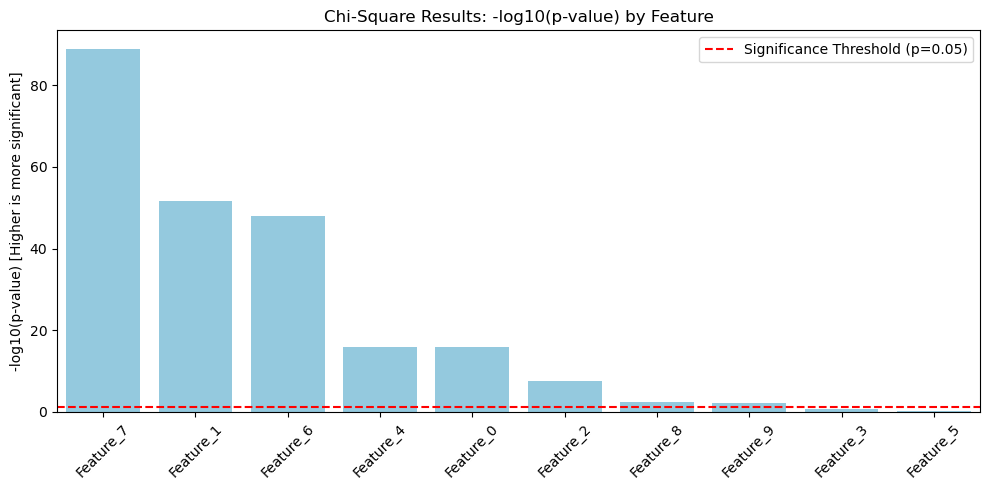

In [13]:

# 2a. Traditional Baseline 1 (Chi-Square Test)
perform_traditional_chi_square(X_train, y_train)


#### Logistic Regression


--- Traditional Baseline 2: Multivariate Logistic Regression ---
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3989
Method:                           MLE   Df Model:                           10
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                  0.2003
Time:                        14:21:59   Log-Likelihood:                -2193.3
converged:                       True   LL-Null:                       -2742.5
Covariance Type:            nonrobust   LLR p-value:                1.168e-229
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2827      0.086      3.296      0.001       0.115       0.451
Feature_0     -1.1253      0.112    -10.038      0.000      -1.34

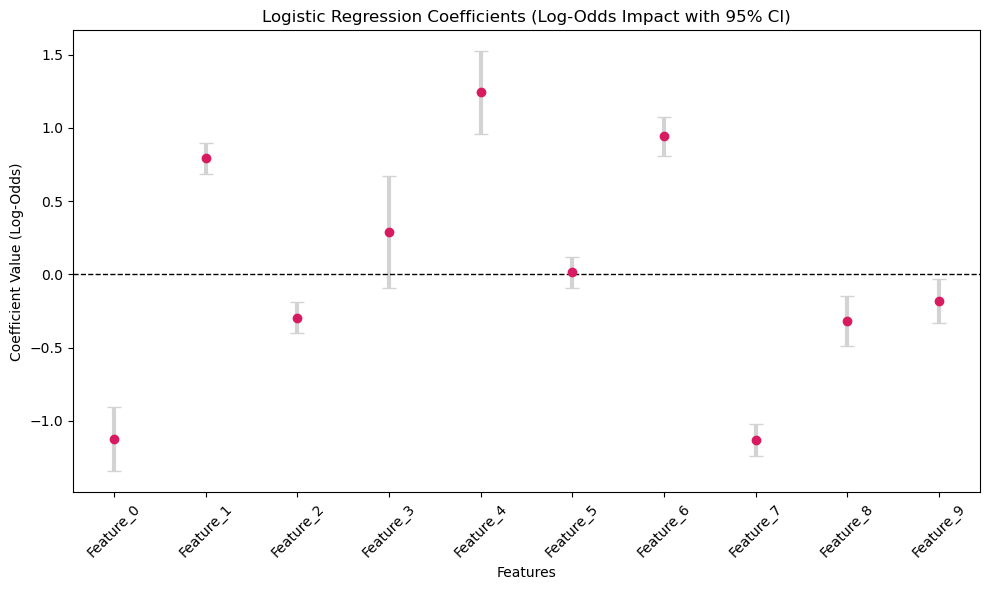

In [14]:

# 2b. Traditional Baseline 2 (Logistic Regression)
perform_traditional_logistic_regression(X_train, y_train)


### make a simple xgboost model for test 2

In [15]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost Classifier)
model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    objective='binary:logistic',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1. Evaluation
evaluate_xgb_classifier(model, X_test_cat, y_test)



--- XGBoost Classifier Performance (Testing) ---
Accuracy: 0.7360
ROC AUC:  0.7749
Log Loss: 0.5572



### look at XGBoost Native Importances

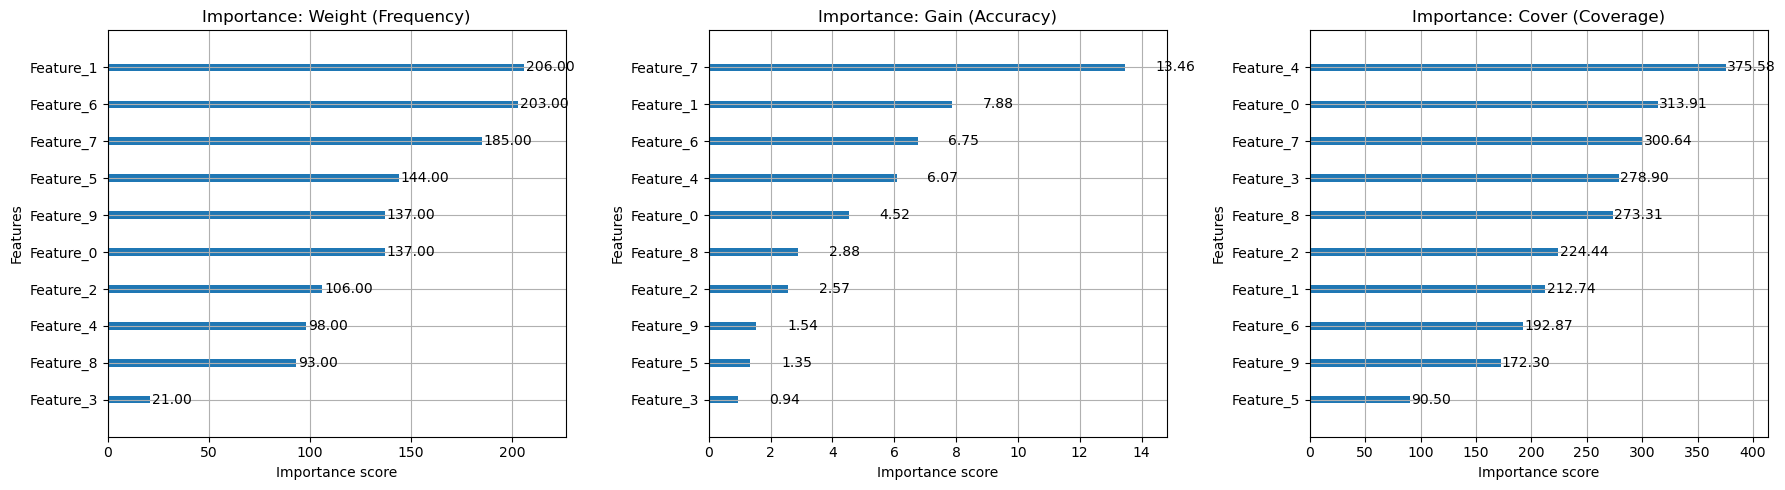

In [16]:

# 5.2. XGBoost Importances
plot_all_xgb_importances(model)


### try to use SHAP to find the influencing inputs

In [17]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

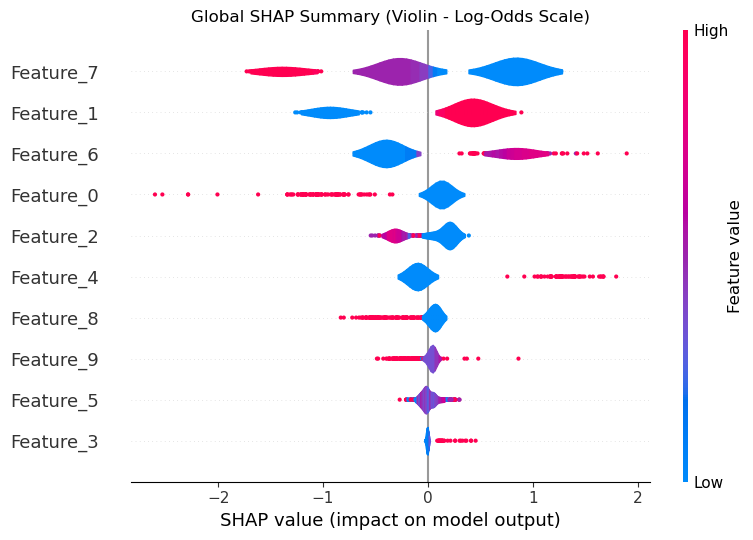

In [18]:

# Global SHAP Violin Summary
plt.title("Global SHAP Summary (Violin - Log-Odds Scale)")
shap.summary_plot(shap_values.values, X_test_cat.astype(float), plot_type="violin", show=False)
plt.show()


Generating SHAP violin grid for all features...


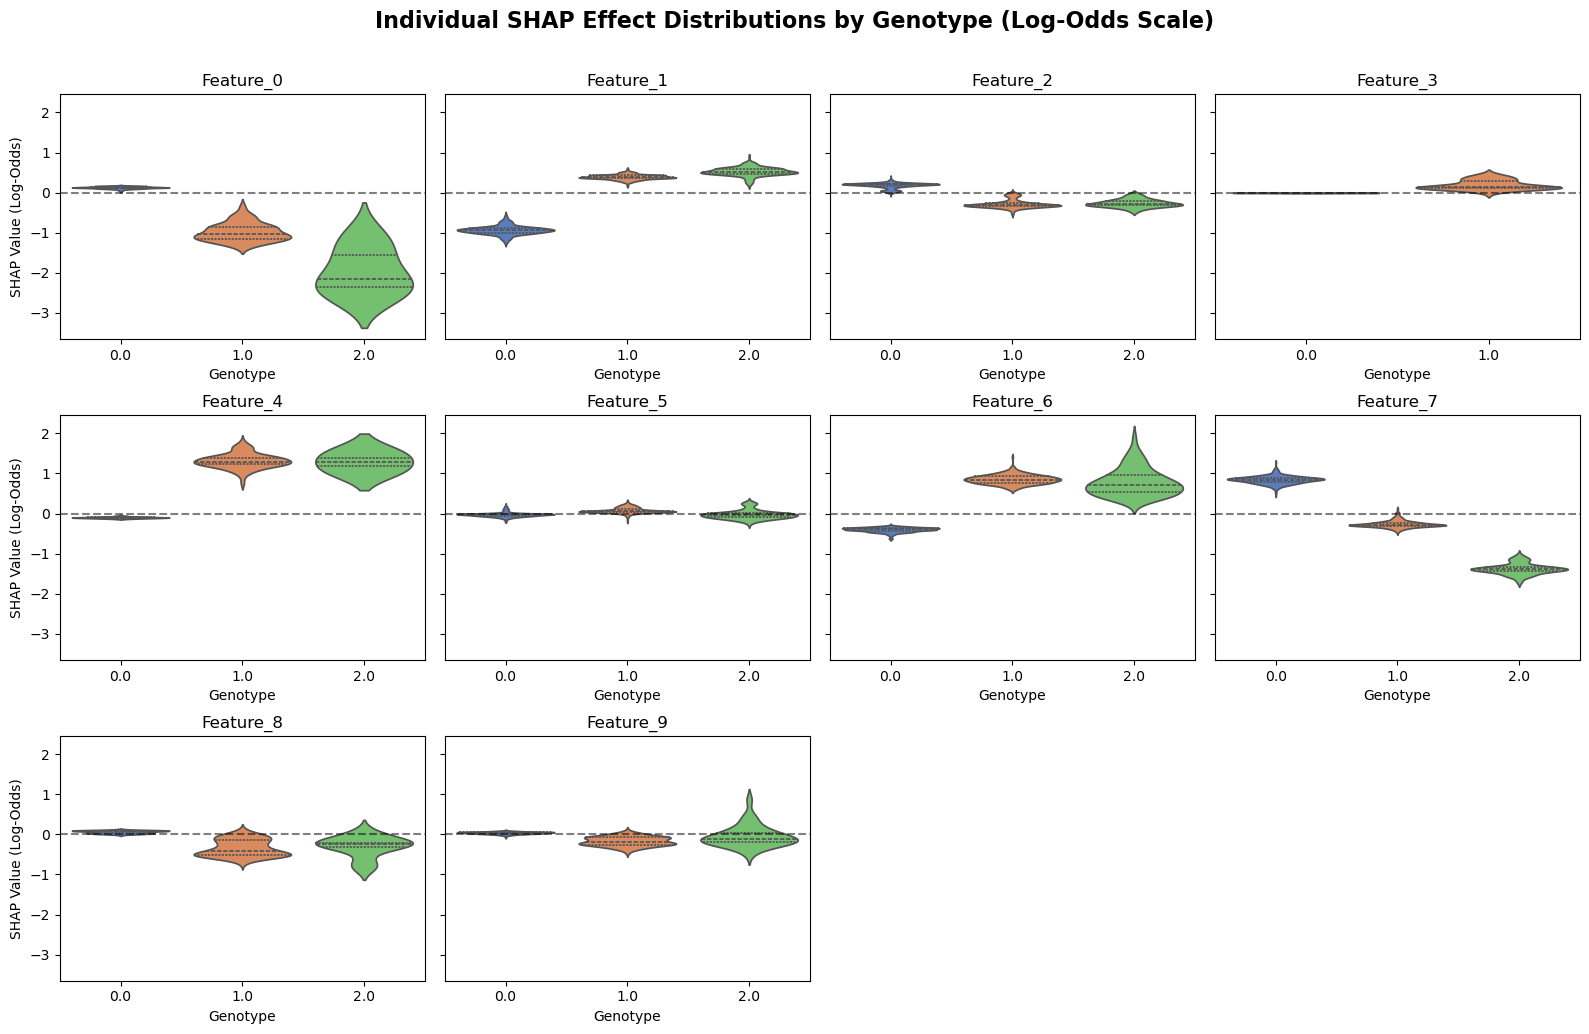

In [19]:

# 7. Individual Feature Violin Plots 
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


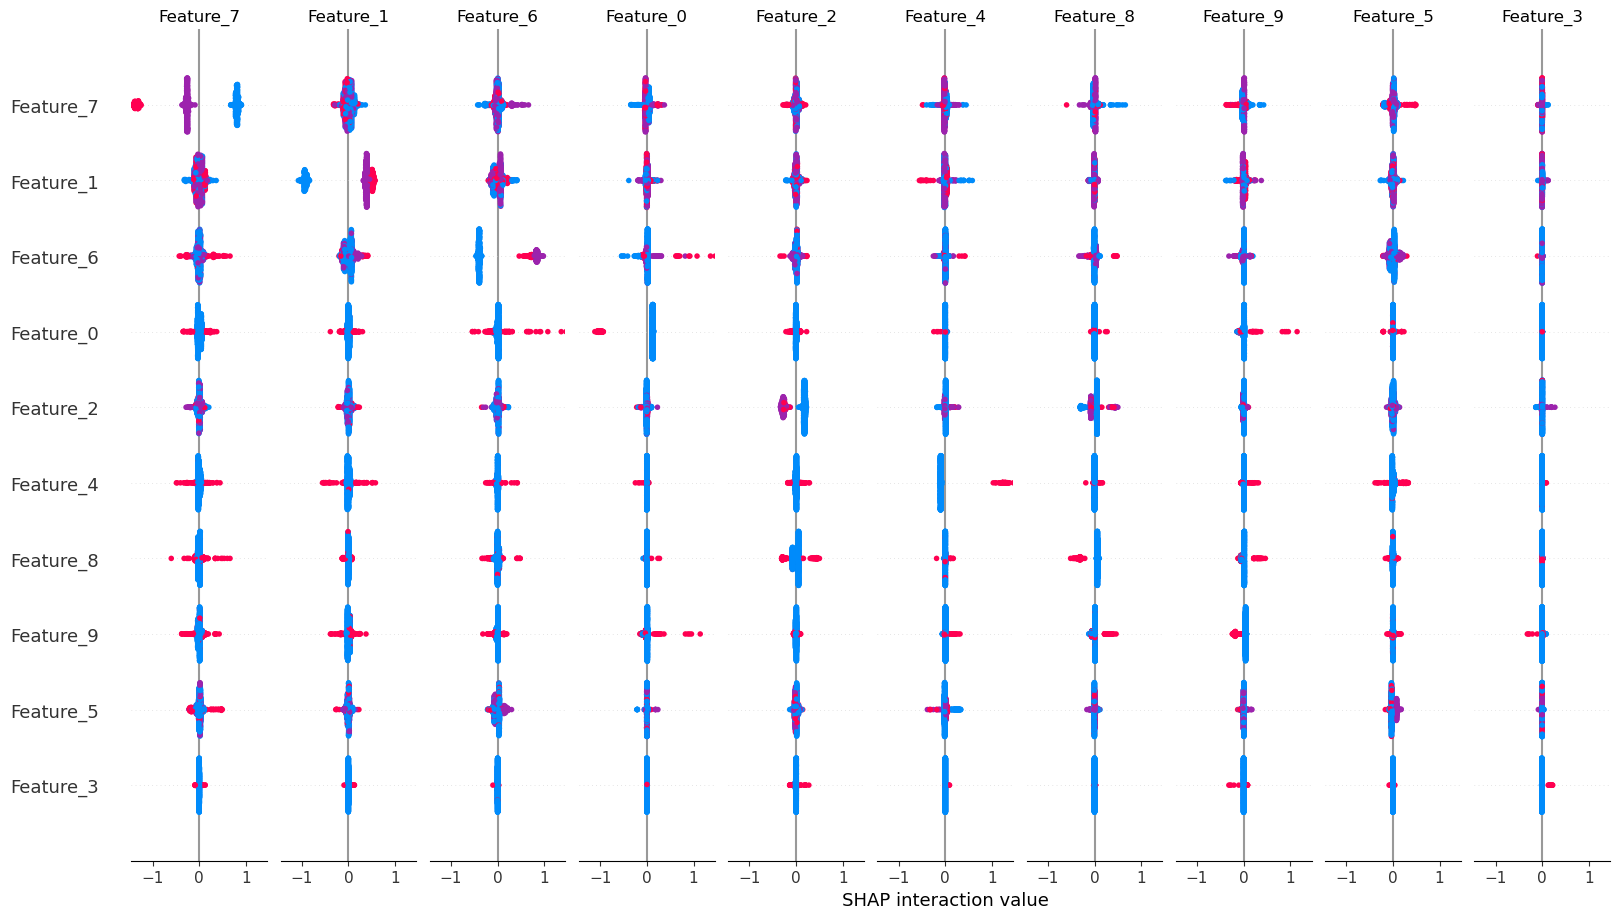


Strongest Interaction found by SHAP: Feature_8 & Feature_2


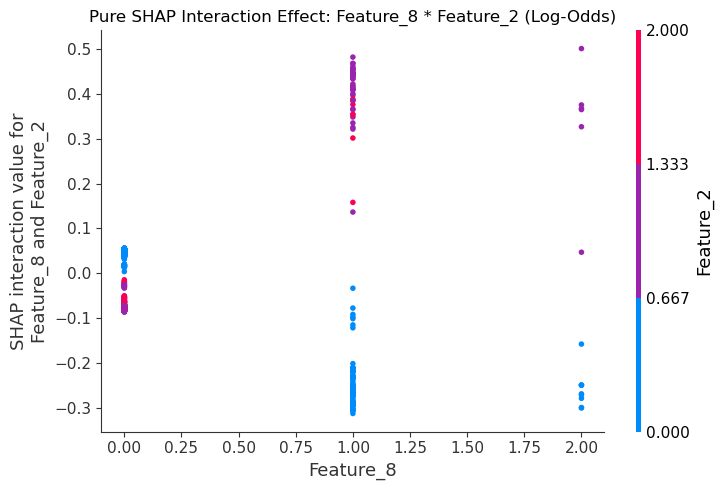

In [20]:

# 8. Deep Dive: Interactions
analyze_shap_interactions(model, X_test_cat)


#### SHAP summry

In [21]:

# Print numerical ranking
print_feature_importance(shap_values)



--- SHAP Feature Importance Ranking (Impact on Log-Odds) ---
  Feature_7: 0.6878
  Feature_1: 0.5806
  Feature_6: 0.5514
  Feature_0: 0.2250
  Feature_2: 0.2170
  Feature_4: 0.1894
  Feature_8: 0.1071
  Feature_9: 0.0688
  Feature_5: 0.0630
  Feature_3: 0.0126


['Feature_7',
 'Feature_1',
 'Feature_6',
 'Feature_0',
 'Feature_2',
 'Feature_4',
 'Feature_8',
 'Feature_9',
 'Feature_5',
 'Feature_3']

## test for addition of hidden features

### make example data 3

In [22]:

# 1. Generate Binary Data
X, X_hidden, y_binary, visible_features, hidden_features = generate_synthetic_classification_data(
    num_inputs=10, 
    num_samples=5000, 
    num_contributing_features=(3, 5), 
    num_hidden_features=(1, 2), 
    weight_range=(-1.5, 1.5), 
    num_interactions=(2, 3), 
    interaction_weight_range=(-1.5, 1.5), 
    noise_std=0.5, 
    hidden_in_linear=True,           
    hidden_in_interactions=True,
)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)


--- Generative Model Info (Log-Odds Formulation) ---
Log-Odds (z) = 
  (1.31 * Feature_7 [recessive]) + 
  (1.23 * Hidden_0 [additive]) + 
  (1.22 * Feature_5 [additive]) + 
  (1.14 * Hidden_1 [dominant]) + 
  (0.87 * Feature_2 [additive]) + 
  (-0.06 * Feature_1 [additive]) + 
  (-1.34 * (Feature_4, Feature_8) [recessive_epistasis]) + 
  (-1.28 * (Feature_2, Feature_5) [multiplicative]) + 
  (-0.54 * (Hidden_0, Hidden_1) [recessive_epistasis]) 
  + Noise(0, 0.5)
Probability (P) = 1 / (1 + e^-z)
Class Output = Binomial(1, P)



### make the Traditional Baselines 

#### Chi-Square Test


--- Traditional Baseline 1: Chi-Square Independence Tests ---
Significant Features (p < 0.05) [Bivariate Test]:
  - Feature_7: p-value = 5.8386e-16
  - Feature_5: p-value = 4.0416e-12
  - Feature_2: p-value = 2.5029e-03


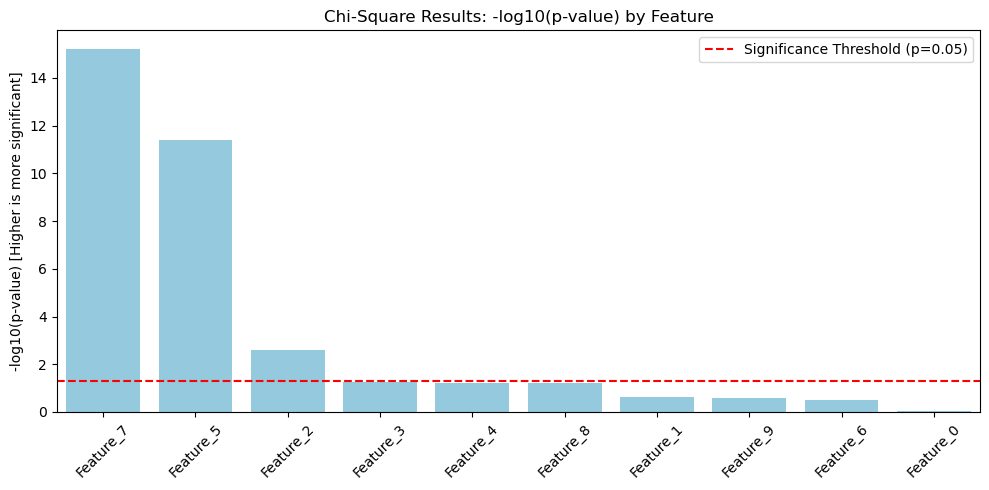

In [23]:

# 2a. Traditional Baseline 1 (Chi-Square Test)
perform_traditional_chi_square(X_train, y_train)


#### Logistic Regression


--- Traditional Baseline 2: Multivariate Logistic Regression ---
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3989
Method:                           MLE   Df Model:                           10
Date:                Sun, 22 Mar 2026   Pseudo R-squ.:                 0.03675
Time:                        14:22:05   Log-Likelihood:                -1682.8
converged:                       True   LL-Null:                       -1747.0
Covariance Type:            nonrobust   LLR p-value:                 9.852e-23
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.1842      0.111     10.680      0.000       0.967       1.402
Feature_0     -0.0235      0.064     -0.365      0.715      -0.15

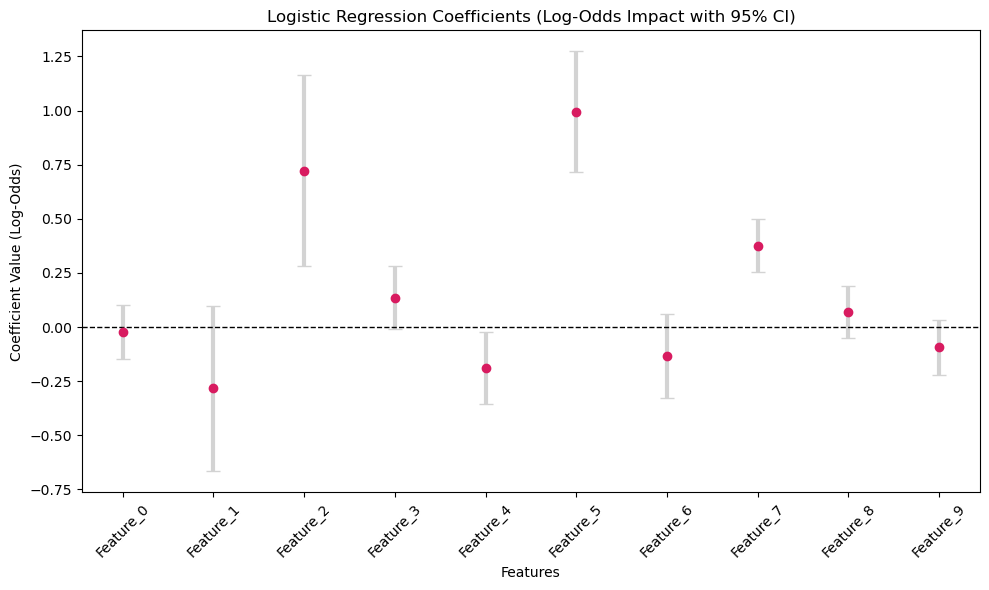

In [24]:

# 2b. Traditional Baseline 2 (Logistic Regression)
perform_traditional_logistic_regression(X_train, y_train)


### make a simple xgboost model for test 3

In [25]:

# 3. Categorical Conversion for XGBoost
X_train_cat = X_train.astype('category')
X_test_cat = X_test.astype('category')

# 4. Machine Learning Modeling (XGBoost Classifier)
model = xgb.XGBClassifier(
    n_estimators=100, 
    max_depth=4, 
    learning_rate=0.1,
    enable_categorical=True,
    tree_method='hist',
    objective='binary:logistic',
    random_state=42
)
model.fit(X_train_cat, y_train)

# 5.1. Evaluation
evaluate_xgb_classifier(model, X_test_cat, y_test)



--- XGBoost Classifier Performance (Testing) ---
Accuracy: 0.8330
ROC AUC:  0.6018
Log Loss: 0.4541



### look at XGBoost Native Importances

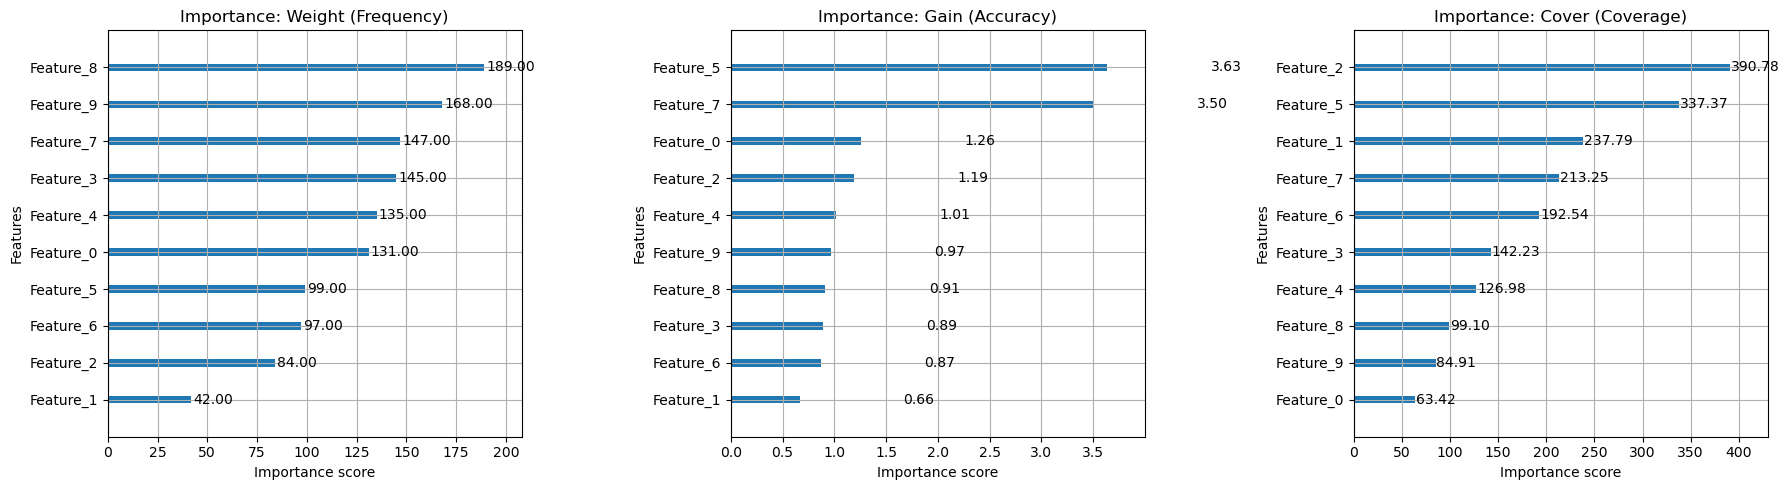

In [26]:

# 5.2. XGBoost Importances
plot_all_xgb_importances(model)


### try to use SHAP to find the influencing inputs

In [27]:

# 6. SHAP Explainability 
print("Computing SHAP values...")
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test_cat)


Computing SHAP values...


#### individual SHAP features ranking

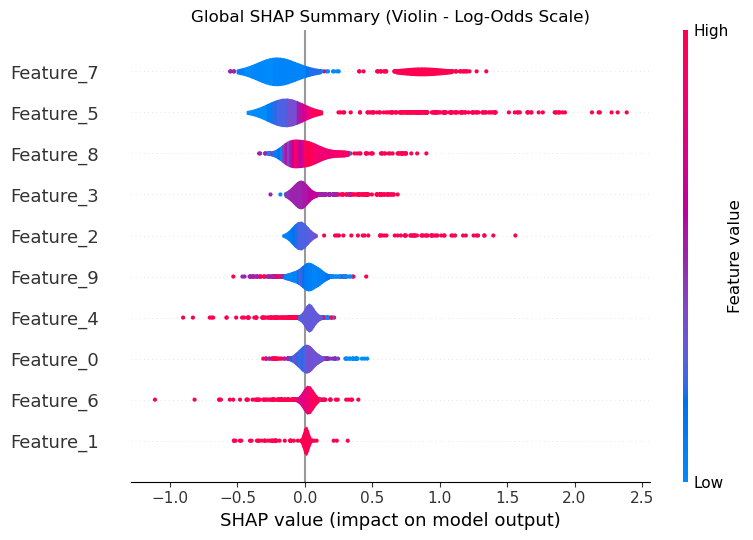

In [28]:

# Global SHAP Violin Summary
plt.title("Global SHAP Summary (Violin - Log-Odds Scale)")
shap.summary_plot(shap_values.values, X_test_cat.astype(float), plot_type="violin", show=False)
plt.show()


Generating SHAP violin grid for all features...


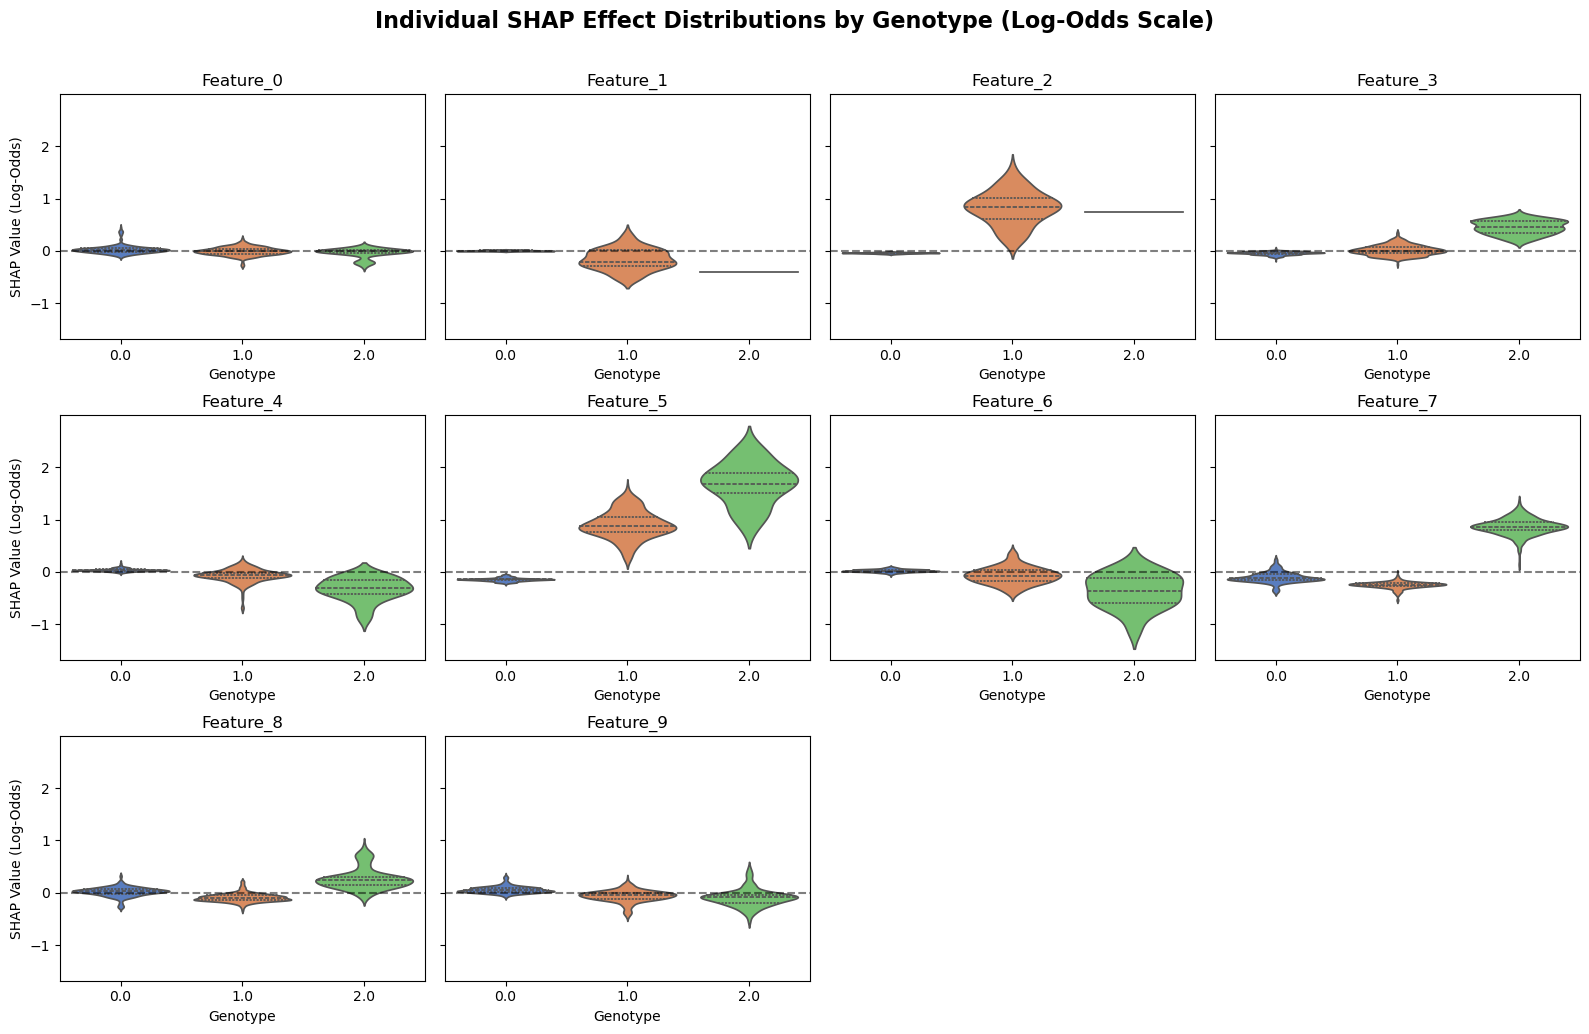

In [29]:

# 7. Individual Feature Violin Plots 
print("Generating SHAP violin grid for all features...")
plot_all_individual_shap_violins(shap_values, X_test_cat, visible_features)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


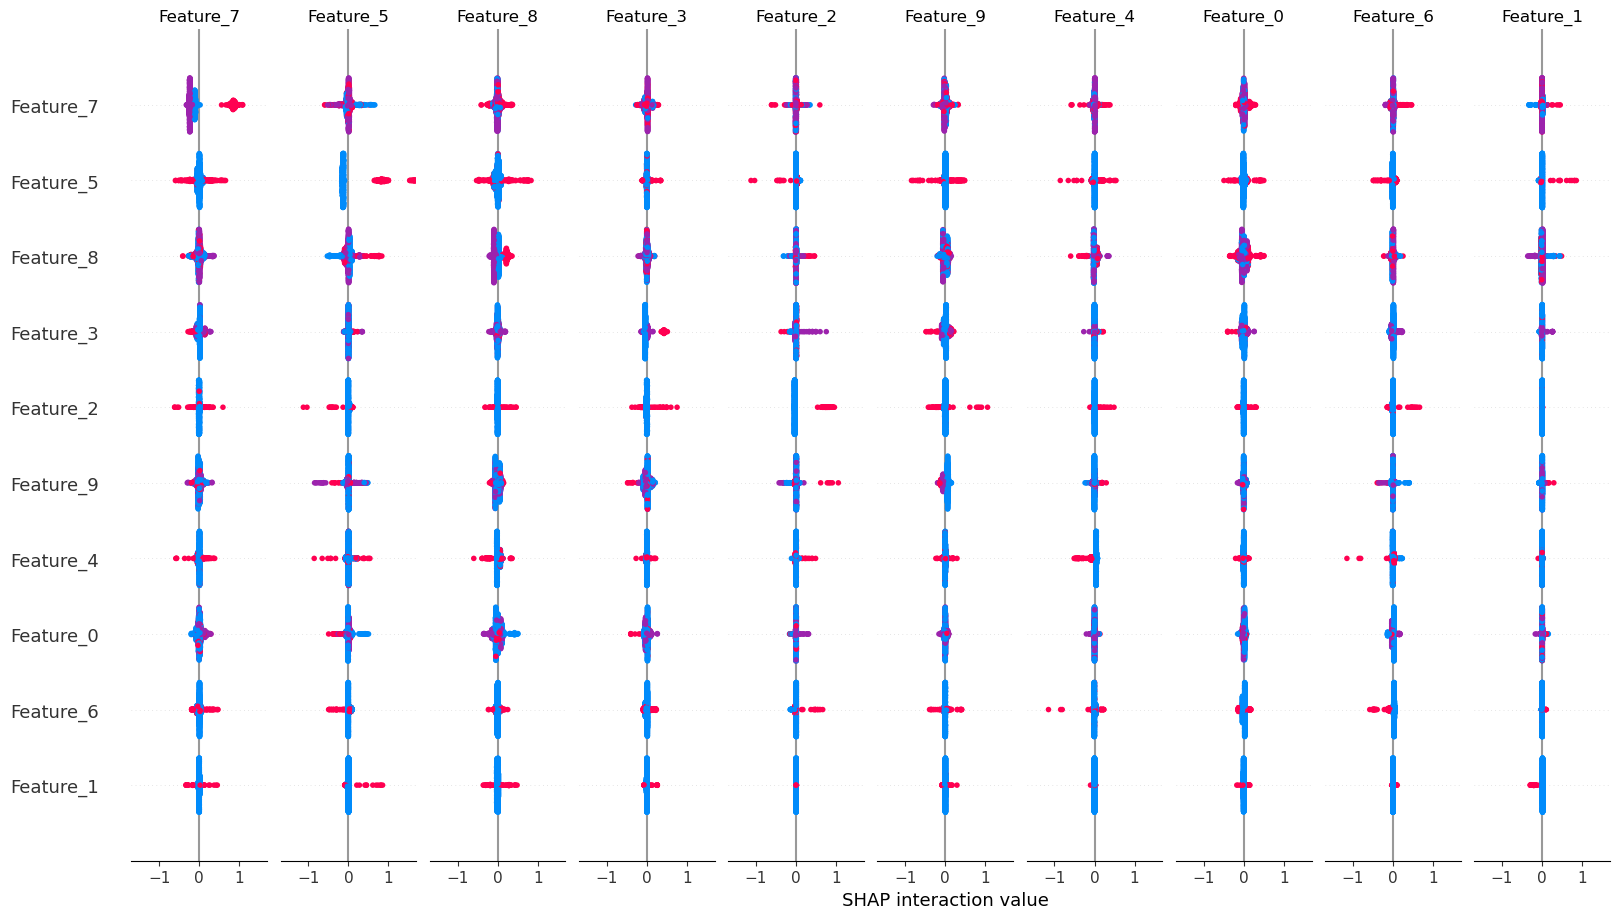


Strongest Interaction found by SHAP: Feature_5 & Feature_8


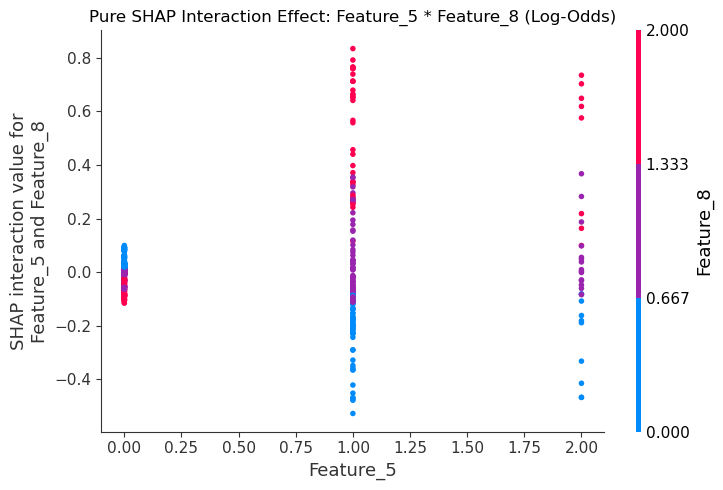

In [30]:

# 8. Deep Dive: Interactions
analyze_shap_interactions(model, X_test_cat)


#### SHAP summry

In [31]:

# Print numerical ranking
print_feature_importance(shap_values)



--- SHAP Feature Importance Ranking (Impact on Log-Odds) ---
  Feature_7: 0.3684
  Feature_5: 0.3206
  Feature_8: 0.1242
  Feature_3: 0.0871
  Feature_2: 0.0822
  Feature_9: 0.0822
  Feature_4: 0.0596
  Feature_0: 0.0572
  Feature_6: 0.0521
  Feature_1: 0.0194


['Feature_7',
 'Feature_5',
 'Feature_8',
 'Feature_3',
 'Feature_2',
 'Feature_9',
 'Feature_4',
 'Feature_0',
 'Feature_6',
 'Feature_1']